# 03 - Schedule-Aware Feature Extraction

Build compact flight-level feature vectors directly from ADS-B pings and schedule windows. The fast path now also keeps `trajectory_sketches.parquet`, a downsampled point-level route sketch used for maps, route deviation, and en-route weather.


## 1. Setup

In [1]:
from pathlib import Path
import sys, json, subprocess, os
import pandas as pd
from IPython.display import display, Image, HTML


def resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root. Run this notebook from the repo or notebooks folder.')

PROJECT_ROOT = resolve_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config
from src.pipeline_reporting import configure_pretty_logging, output_dir, save_dataset_inventory, save_dataframe, save_table_image, save_bar_chart

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
paths = config['paths']
processed_dir = PROJECT_ROOT / paths.get('processed_data_dir', 'data/processed')
raw_dir = PROJECT_ROOT / paths.get('raw_data_dir', 'data/raw')
outputs_dir = PROJECT_ROOT / 'outputs'
notebook_out = output_dir('03_feature_extraction', root=outputs_dir / 'notebook_reports')
log_file = configure_pretty_logging(PROJECT_ROOT / 'logs', '03_feature_extraction')
print('Project root:', PROJECT_ROOT)
print('Notebook output dir:', notebook_out)
print('Notebook log file:', log_file)

Project root: C:\Code\flight-disruption-prediction
Notebook output dir: C:\Code\flight-disruption-prediction\outputs\notebook_reports\03_feature_extraction
Notebook log file: C:\Code\flight-disruption-prediction\logs\03_feature_extraction_20260421_153320.log


## 2. Controls

In [2]:
RUN_FEATURE_EXTRACTION = False
FORCE_FEATURE_EXTRACTION = True
print('Feature mode:', config.get('features', {}).get('mode'))
print('RUN_FEATURE_EXTRACTION:', RUN_FEATURE_EXTRACTION)

Feature mode: schedule_aware_direct
RUN_FEATURE_EXTRACTION: False


## 3. Run Feature Stage

In [3]:
if RUN_FEATURE_EXTRACTION:
    import main as pipeline_main
    from src.data_validator import DataValidator
    validator = DataValidator(mode=config.get('validation_mode', 'warn_only'), log_dir=PROJECT_ROOT / 'logs')
    pipeline_main.stage_features(config, validator, force=FORCE_FEATURE_EXTRACTION)
else:
    print('Feature extraction skipped. Set RUN_FEATURE_EXTRACTION=True to rebuild.')

Feature extraction skipped. Set RUN_FEATURE_EXTRACTION=True to rebuild.


## 4. Feature Output Summary

Feature file: C:\Code\flight-disruption-prediction\data\processed\trajectory_features.parquet
Shape: (84916, 58)


,trajectory_id,icao24,callsign,timestamp,start_time_utc,end_time_utc,dep_anchor_confidence,arr_anchor_confidence,dep_anchor_is_partial,arr_anchor_is_partial,...,enroute_weather_coverage_ratio,enroute_temperature_mean,enroute_temperature_min,enroute_temperature_max,enroute_wind_speed_mean,enroute_wind_speed_max,enroute_precipitation_mean,enroute_precipitation_max,enroute_weather_severity_mean,enroute_weather_severity_max
0,FFT2130_202205020707_F9213020220502,a1ba0f,FFT2130,1.651477e+09,2022-05-02 07:36:00+00:00,2022-05-02 10:50:10+00:00,1.0,1.0,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FFT2130_202205091400_F9213020220509,a3c900,FFT2130,1.652105e+09,2022-05-09 14:02:10+00:00,2022-05-09 17:13:40+00:00,1.0,1.0,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FFT2130_202205161400_F9213020220516,a3b414,FFT2130,1.652710e+09,2022-05-16 14:02:40+00:00,2022-05-16 17:27:20+00:00,1.0,1.0,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FFT2130_202205231400_F9213020220523,a21f57,FFT2130,1.653318e+09,2022-05-23 14:52:30+00:00,2022-05-23 18:08:40+00:00,1.0,1.0,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FFT2130_202205301450_F9213020220530,a4380f,FFT2130,1.653923e+09,2022-05-30 15:08:40+00:00,2022-05-30 18:15:30+00:00,1.0,1.0,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,status,count
0,full_flight,40160
1,partial_end_missing,19296
2,partial_start_missing,17692
3,airborne_only,6688
4,ground_only,1080


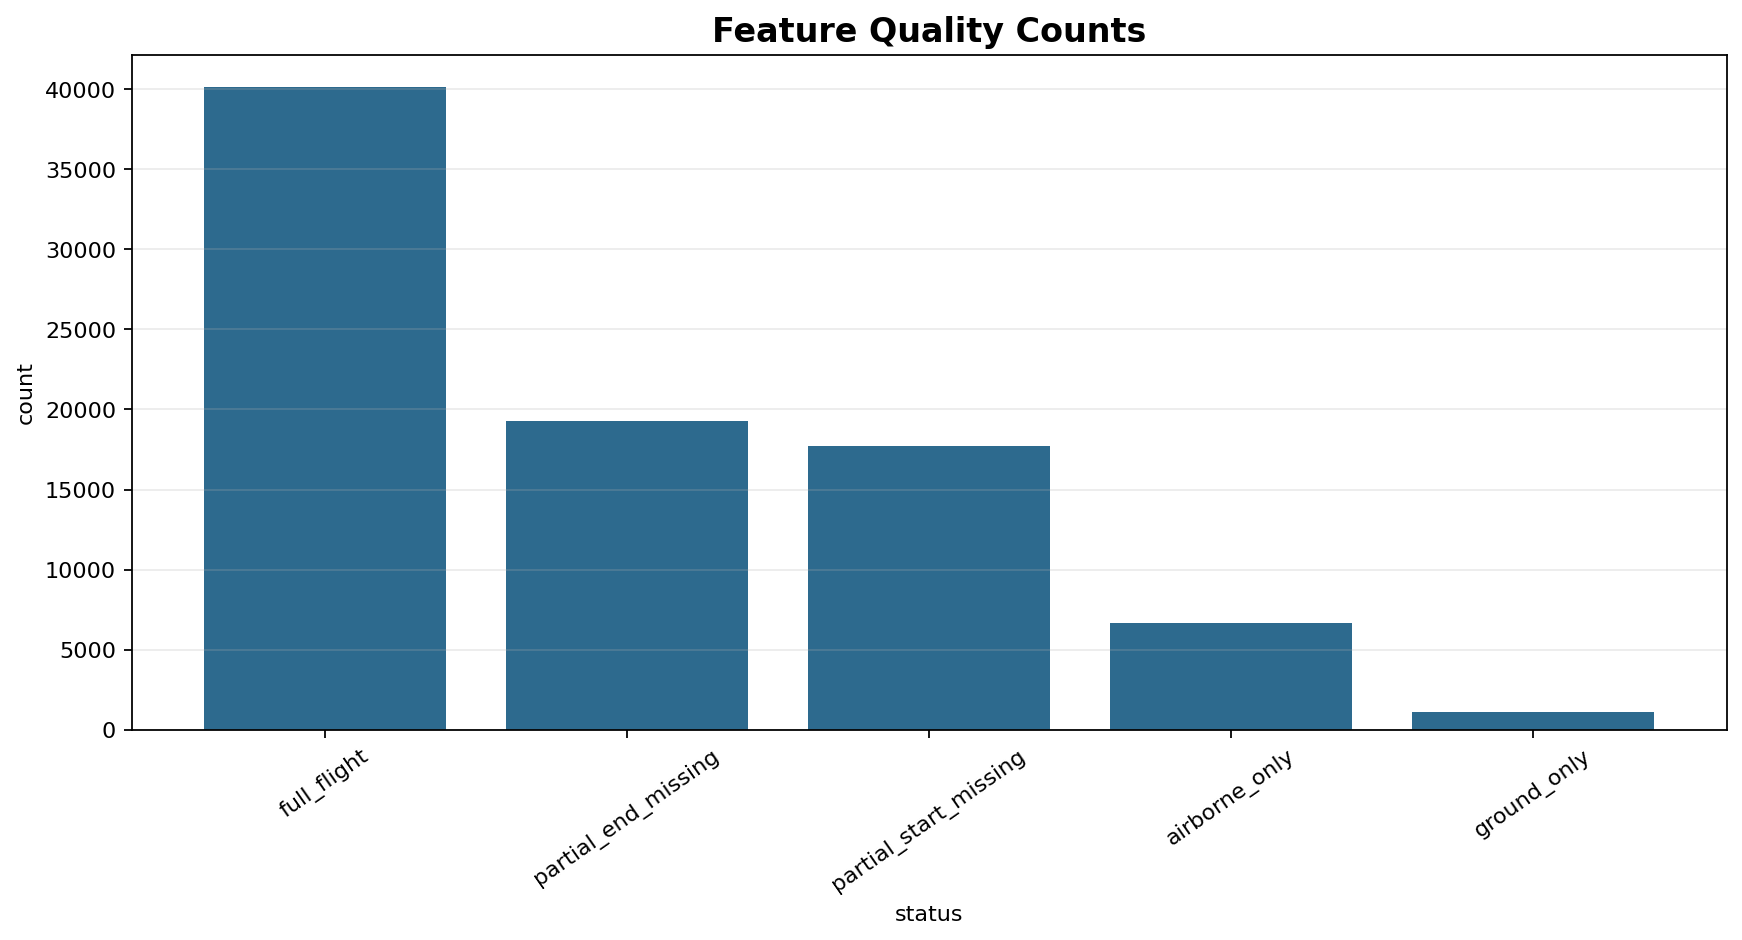


Trajectory sketch file: C:\Code\flight-disruption-prediction\data\processed\trajectory_sketches.parquet
Sketch shape: (1377157, 25)


,trajectory_id,flight_key,callsign,icao24,point_idx,timestamp,timestamp_utc,elapsed_minutes,flight_progress,latitude,...,on_ground,origin,destination,scheduled_dep,scheduled_arr,trajectory_quality_status,trajectory_quality_score,is_full_flight,source,sketch_interval_seconds
0,FFT2130_202205020707_F9213020220502,F92130_20220502,FFT2130,a1ba0f,0,1651476960,2022-05-02 07:36:00+00:00,0.000000,0.000000,NaN,...,False,KLAS,KDTW,2022-05-02 07:07:00+00:00,2022-05-02 11:07:00+00:00,full_flight,1.0,True,schedule_aware_direct,600
1,FFT2130_202205020707_F9213020220502,F92130_20220502,FFT2130,a1ba0f,1,1651477560,2022-05-02 07:46:00+00:00,10.000000,0.051502,36.178345,...,False,KLAS,KDTW,2022-05-02 07:07:00+00:00,2022-05-02 11:07:00+00:00,full_flight,1.0,True,schedule_aware_direct,600
2,FFT2130_202205020707_F9213020220502,F92130_20220502,FFT2130,a1ba0f,2,1651478160,2022-05-02 07:56:00+00:00,20.000000,0.103004,36.471405,...,False,KLAS,KDTW,2022-05-02 07:07:00+00:00,2022-05-02 11:07:00+00:00,full_flight,1.0,True,schedule_aware_direct,600
3,FFT2130_202205020707_F9213020220502,F92130_20220502,FFT2130,a1ba0f,3,1651478760,2022-05-02 08:06:00+00:00,30.000000,0.154506,36.876914,...,False,KLAS,KDTW,2022-05-02 07:07:00+00:00,2022-05-02 11:07:00+00:00,full_flight,1.0,True,schedule_aware_direct,600
4,FFT2130_202205020707_F9213020220502,F92130_20220502,FFT2130,a1ba0f,4,1651479620,2022-05-02 08:20:20+00:00,44.333333,0.228326,37.535660,...,False,KLAS,KDTW,2022-05-02 07:07:00+00:00,2022-05-02 11:07:00+00:00,full_flight,1.0,True,schedule_aware_direct,600


,metric,value
0,sketch_rows,1377157.0
1,trajectories,84916.0
2,median_points_per_trajectory,15.0
3,max_points_per_trajectory,67.0


In [4]:
feature_path = processed_dir / paths.get('features_file', 'trajectory_features.parquet')
sketch_path = processed_dir / paths.get('trajectory_sketches_file', 'trajectory_sketches.parquet')
if feature_path.exists():
    df_features = pd.read_parquet(feature_path)
    print('Feature file:', feature_path)
    print('Shape:', df_features.shape)
    display(df_features.head())
    save_dataframe(df_features.head(200), 'feature_preview', notebook_out)
    save_table_image(df_features.head(20), 'feature_preview', notebook_out, title='Feature Preview')
    if 'trajectory_quality_status' in df_features.columns:
        q = df_features['trajectory_quality_status'].value_counts(dropna=False).rename_axis('status').reset_index(name='count')
        save_dataframe(q, 'feature_quality_counts', notebook_out)
        save_bar_chart(q, 'status', 'count', 'feature_quality_counts', notebook_out, title='Feature Quality Counts')
        display(q)
        display(Image(filename=str(notebook_out / 'feature_quality_counts.png')))
else:
    print('No feature output found yet.')

if sketch_path.exists():
    try:
        df_sketch = pd.read_parquet(sketch_path)
    except Exception as exc:
        print(f'Trajectory sketch file exists but could not be read: {sketch_path}')
        print(f'Regenerate it by rerunning this notebook with RUN_FEATURE_EXTRACTION=True. Error: {exc}')
        df_sketch = pd.DataFrame()

    if not df_sketch.empty:
        print('\nTrajectory sketch file:', sketch_path)
        print('Sketch shape:', df_sketch.shape)
        display(df_sketch.head())
        sketch_summary = pd.DataFrame({
            'metric': ['sketch_rows', 'trajectories', 'median_points_per_trajectory', 'max_points_per_trajectory'],
            'value': [
                len(df_sketch),
                df_sketch['trajectory_id'].nunique() if 'trajectory_id' in df_sketch else 0,
                df_sketch.groupby('trajectory_id').size().median() if 'trajectory_id' in df_sketch else 0,
                df_sketch.groupby('trajectory_id').size().max() if 'trajectory_id' in df_sketch else 0,
            ]
        })
        save_dataframe(sketch_summary, 'trajectory_sketch_summary', notebook_out)
        save_table_image(sketch_summary, 'trajectory_sketch_summary', notebook_out, title='Trajectory Sketch Summary')
        display(sketch_summary)
else:
    print('No trajectory sketch output found yet. Run feature extraction with save_trajectory_sketches=true.')


## 5. Route Map and Altitude Preview

Uses `trajectory_sketches.parquet` to save and display one representative route map plus altitude profile. If sketches do not exist yet, rerun feature extraction first.


,status,trajectory_id,point_count,map_html,altitude_png,points_csv
0,success,NKS993_202205301115_NK99320220530,62,C:\Code\flight-disruption-prediction\outputs\n...,C:\Code\flight-disruption-prediction\outputs\n...,C:\Code\flight-disruption-prediction\outputs\n...


Trajectory: NKS993_202205301115_NK99320220530
Map HTML: C:\Code\flight-disruption-prediction\outputs\notebook_reports\03_feature_extraction\trajectory_preview\NKS993_202205301115_NK99320220530_route_map.html
Altitude PNG: C:\Code\flight-disruption-prediction\outputs\notebook_reports\03_feature_extraction\trajectory_preview\NKS993_202205301115_NK99320220530_altitude_profile.png


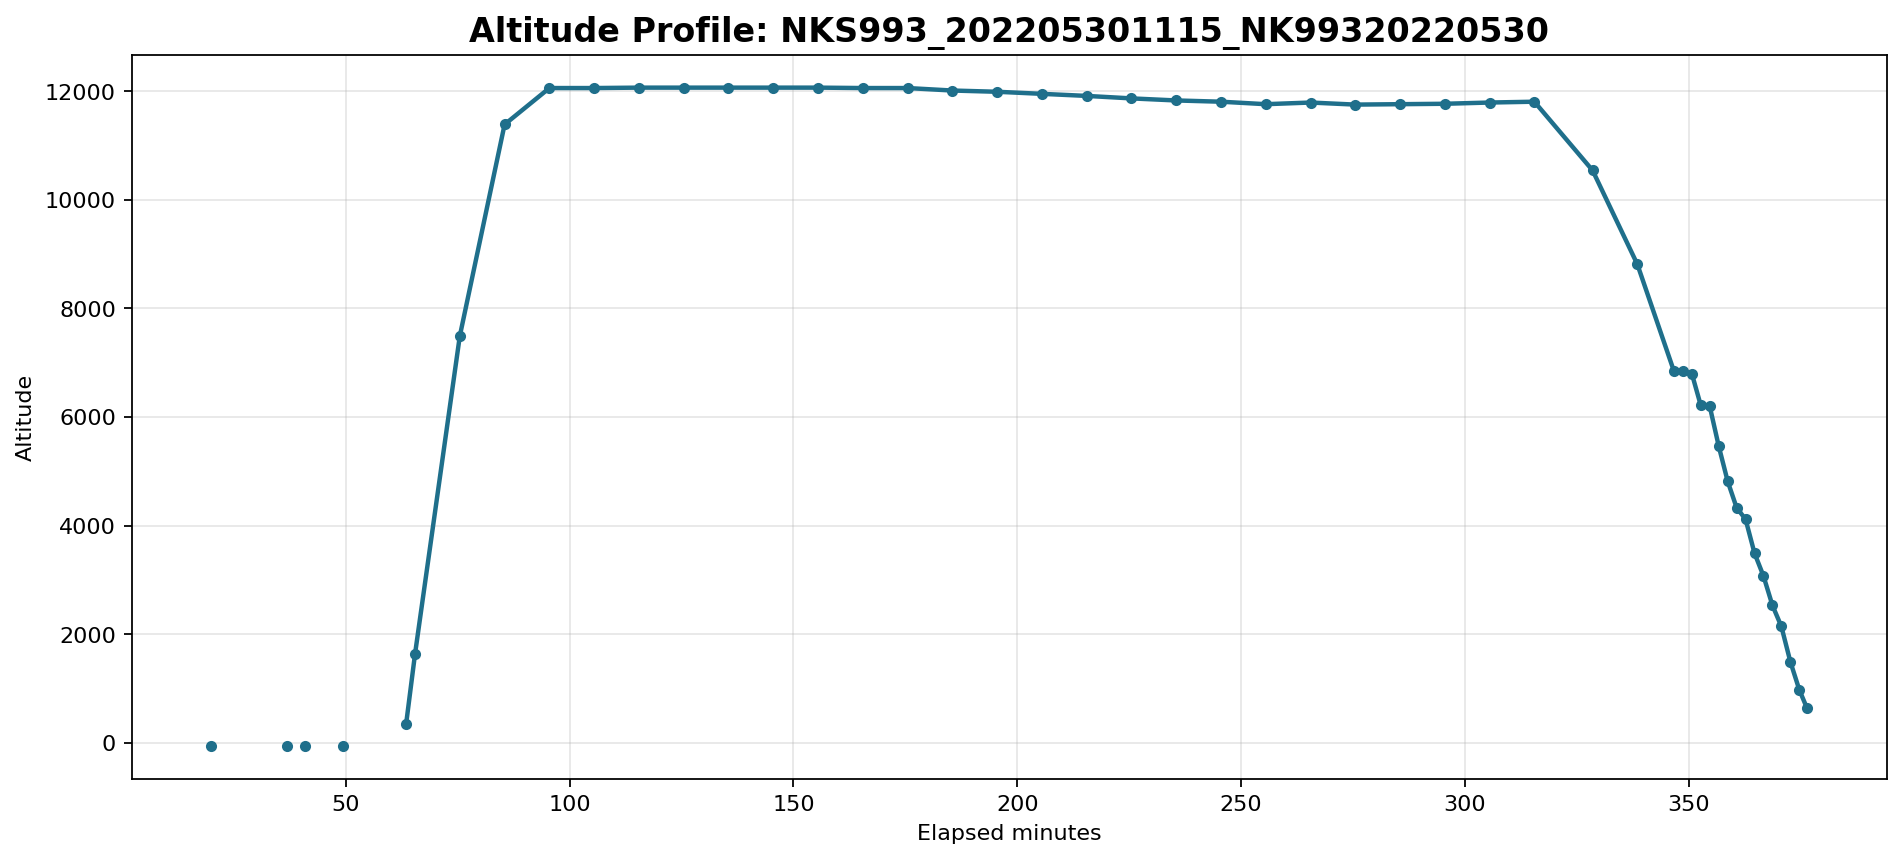

In [5]:
from IPython.display import IFrame
from src.trajectory_preview import generate_trajectory_preview

preview = generate_trajectory_preview(
    sketches_path=processed_dir / paths.get('trajectory_sketches_file', 'trajectory_sketches.parquet'),
    features_path=processed_dir / paths.get('features_file', 'trajectory_features.parquet'),
    out_dir=notebook_out / 'trajectory_preview',
)

display(pd.DataFrame([preview]))
if preview.get('status') == 'success':
    print('Trajectory:', preview['trajectory_id'])
    print('Map HTML:', preview['map_html'])
    print('Altitude PNG:', preview['altitude_png'])
    display(IFrame(src=preview['map_html'], width='100%', height=560))
    display(Image(filename=preview['altitude_png']))
else:
    print(preview.get('message'))
